In [1]:
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
from scipy.interpolate import interpn
import plotly.graph_objects as go
from plotly.subplots import make_subplots
from functions import *

In [2]:
# u_data = read_pws_file("../data/111/PWS_NASA_Dataset111_u.faa")
# v_data = read_pws_file("../data/111/PWS_NASA_Dataset111_v.faa")
# w_data = read_pws_file("../data/111/PWS_NASA_Dataset111_w.faa")

u_data = read_pws_file("../data/DO-220B Reference Supplement/ADWRS/PWS_NASA_Dataset351_W9_4/PWS_NASA_Dataset351_u.faa")
v_data = read_pws_file("../data/DO-220B Reference Supplement/ADWRS/PWS_NASA_Dataset351_W9_4/PWS_NASA_Dataset351_v.faa")
w_data = read_pws_file("../data/DO-220B Reference Supplement/ADWRS/PWS_NASA_Dataset351_W9_4/PWS_NASA_Dataset351_w.faa")

In [3]:
# ix, iy, iz = u_data['dimensions']
# xstart, ystart, zstart = u_data['origin_m']
# dx, dy, dz = u_data['resolution_m']

# #сетки координат
# x = np.arange(xstart, xstart + ix * dx, dx)
# y = np.arange(ystart, ystart + iy * dy, dy)
# z = np.arange(zstart, zstart + iz * dz, dz)
# X, Y, Z = np.meshgrid(x, y, z, indexing='ij')

# # Заданная точка
# x0, y0, z0 = 0, 0, 0  

# # Вычисление разностей координат
# delta_x = X - x0
# delta_y = Y - y0
# delta_z = Z - z0

# distance = np.sqrt(delta_x**2 + delta_y**2 + delta_z**2)

# distance[distance == 0] = 1e-10

# # Расчет радиальной скорости
# U = u_data['data']
# V = v_data['data']
# W = w_data['data']
# radial_velocity = (U * delta_x + V * delta_y + W * delta_z) / distance



# z_slice = 3

# # print("Размерность поля радиальных скоростей:", radial_velocity.shape)


# plt.figure(figsize=(10, 7))
# plt.imshow(
#     radial_velocity[:, :, z_slice],
#     cmap='coolwarm',
#     origin='lower',
#     extent=[x.min(), x.max(), y.min(), y.max()]
# )
# plt.colorbar(label='Радиальная скорость (м/с)')
# plt.title(f'Радиальная скорость\nСрез по z = {z_slice * dz + zstart:.2f} м')

# plt.scatter(-3900, -3900, color='red', marker='X', s=100, label='Наблюдатель') 
# plt.legend()

# plt.xlabel('X (метры)')
# plt.ylabel('Y (метры)')
# plt.show()

# # --- 3D-график ---
# fig = plt.figure(figsize=(10, 7))
# ax = fig.add_subplot(111, projection='3d')

# scatter = ax.scatter(
#     X[:, :, z_slice].flatten(),
#     Y[:, :, z_slice].flatten(),
#     Z[:, :, z_slice].flatten(),
#     c=radial_velocity[:, :, z_slice].flatten(),
#     cmap='coolwarm'
# )

# ax.scatter(x0, y0, z0, color='red', marker='X', s=200, label='Наблюдатель') 

# cbar = fig.colorbar(scatter, ax=ax, shrink=0.5, aspect=10)
# cbar.set_label('Radial Velocity (m/s)', rotation=270, labelpad=15)
# ax.set_xlabel('X')
# ax.set_ylabel('Y')
# ax.set_zlabel('Z')
# plt.title(f'Радиальная скорость\nСрез по z = {z_slice * dz + zstart:.2f} м')
# plt.legend()

# plt.show()

In [4]:

def spherical_to_cartesian(azimuth_deg, elevation_deg):
    """Конвертируем углы в направляющий вектор"""
    azimuth = np.radians(azimuth_deg)
    elevation = np.radians(elevation_deg)
    x = np.cos(elevation) * np.cos(azimuth)
    y = np.cos(elevation) * np.sin(azimuth)
    z = np.sin(elevation)
    return np.array([x, y, z])

def line_parametric(t, origin, direction):
    """Параметрическое уравнение прямой"""
    return origin + direction * t

def find_intersection(matrix_shape, origin, direction):
    """Находим точки пересечения прямой с границами матрицы"""
    def get_t(axis, boundary):
        return (boundary - origin[axis]) / direction[axis] if direction[axis] != 0 else np.nan
    
    min_bounds = np.array([0, 0, 0])
    max_bounds = np.array(matrix_shape) - 1e-6  #  краевые эффекты
    
    t_enter = []
    t_exit = []
    
    for i in range(3):
        t1 = get_t(i, min_bounds[i])
        t2 = get_t(i, max_bounds[i])
        t_enter.append(min(t1, t2))
        t_exit.append(max(t1, t2))
    
    # Исправленный блок 
    valid_t_enter = [t for t in t_enter if not np.isnan(t)]
    valid_t_exit = [t for t in t_exit if not np.isnan(t)]
    
    t_start = max([0] + valid_t_enter) if valid_t_enter else np.nan 
    t_end = min(valid_t_exit) if valid_t_exit else np.nan    
    
    if np.isnan(t_start) or np.isnan(t_end) or t_start > t_end:
        return np.nan, np.nan
    
    
    # t_start = max(0, *[t for t in t_enter if not np.isnan(t)])
    # t_end = min(*[t for t in t_exit if not np.isnan(t)])
    
    return t_start, t_end

def trilinear_interpolation(matrix, x, y, z):
    """Трилинейная интерполяция"""
    x0, y0, z0 = np.floor([x, y, z]).astype(int)
    x1, y1, z1 = x0 + 1, y0 + 1, z0 + 1
    
    # обработка выхода за границы
    x0, x1 = np.clip([x0, x1], 0, matrix.shape[0]-1)
    y0, y1 = np.clip([y0, y1], 0, matrix.shape[1]-1)
    z0, z1 = np.clip([z0, z1], 0, matrix.shape[2]-1)
    
    xd = (x - x0) / (x1 - x0) if (x1 - x0) != 0 else 0
    yd = (y - y0) / (y1 - y0) if (y1 - y0) != 0 else 0
    zd = (z - z0) / (z1 - z0) if (z1 - z0) != 0 else 0

    c00 = matrix[x0, y0, z0] * (1 - xd) + matrix[x1, y0, z0] * xd
    c01 = matrix[x0, y0, z1] * (1 - xd) + matrix[x1, y0, z1] * xd
    c10 = matrix[x0, y1, z0] * (1 - xd) + matrix[x1, y1, z0] * xd
    c11 = matrix[x0, y1, z1] * (1 - xd) + matrix[x1, y1, z1] * xd

    c0 = c00 * (1 - yd) + c10 * yd
    c1 = c01 * (1 - yd) + c11 * yd

    return c0 * (1 - zd) + c1 * zd


In [5]:
def plot_line_results(V_radial, z0, x, y, z,  points, radial_velocity_values, distance, observer_position):
    """
    Визуализация результатов: радиальная скорость и профиль скорости.
    
    Args:
        V_radial (np.ndarray): 3D массив радиальных скоростей.
        z0 (int): Величина в метрах среза  Z.
        x (np.ndarray): Координаты по оси X.
        y (np.ndarray): Координаты по оси Y.
        points (np.ndarray): Точки на линии.
        radial_velocity_values (list): Значения радиальной скорости в точках.
        distance (np.ndarray): Расстояния между точками.
        observer_position (tuple): Позиция наблюдателя (x0, y0).
    """
    import matplotlib.pyplot as plt
    z_slice = np.argmin(np.abs(z - z0))  # Индекс слоя z

    # Срез радиальной скорости
    radial_slice = V_radial[:, :, z_slice]

    plt.figure(figsize=(14, 6))

    # Подграфик 1: Вид сверху
    plt.subplot(1, 2, 1)
    plt.imshow(
        radial_slice.T,
        extent=[x.min(), x.max(), y.min(), y.max()],
        origin='lower',
        cmap='coolwarm',
        alpha=0.6
    )
    plt.colorbar(label='Радиальная скорость (м/с)')

    # Точки линии
    plt.scatter(
        points[:, 0], points[:, 1],
        c=radial_velocity_values, cmap='coolwarm', s=50, edgecolor='w',
        label='Точки линии'
    )
    plt.plot(points[:, 0], points[:, 1], color='blue', linestyle='-', linewidth=2, label='Линия')
    
    # Наблюдатель
    plt.scatter(
        observer_position[0]+0, observer_position[1]+0,
        color='red', marker='X', s=100, label='Наблюдатель'
    )

    # Подписи значений у точек
    for i in range(len(points)):
        plt.text(
            points[i, 0], points[i, 1],
            f'{radial_velocity_values[i]:.1f} м/с',
            fontsize=8,
            ha='right',
            va='bottom',
            color='black',
            bbox=dict(boxstyle='round,pad=0.2',
                      edgecolor='white',
                      facecolor='white',
                      alpha=0.7)
        )

    plt.xlabel('X (м)')
    plt.ylabel('Y (м)')
    plt.title(f'Вид сверху (z={z0} м)')
    plt.legend()
    plt.grid(True)

    # Подграфик 2: Профиль скорости
    plt.subplot(1, 2, 2)
    plt.plot(distance, radial_velocity_values, marker='o', linestyle='-', color='b')
    plt.xlabel('Расстояние вдоль линии (м)')
    plt.ylabel('Радиальная скорость (м/с)')
    plt.title('Профиль радиальной скорости')
    plt.grid(True)

    # Подписи значений у профиля
    for i in range(len(distance)):
        plt.text(
            distance[i], radial_velocity_values[i],
            f'{radial_velocity_values[i]:.1f} м/с',
            fontsize=8,
            ha='right',
            va='bottom',
            color='black',
            bbox=dict(boxstyle='round,pad=0.2',
                      edgecolor='white',
                      facecolor='white',
                      alpha=0.7)
        )

    plt.tight_layout()
    plt.show()

[[-4000.             0.            80.27368991]
 [-3578.94737105     0.           122.52300012]
 [-3157.89474211     0.           164.77231034]
 [-2736.84211316     0.           207.02162055]
 [-2315.78948421     0.           249.27093076]
 [-1894.73685526     0.           291.52024098]
 [-1473.68422632     0.           333.76955119]
 [-1052.63159737     0.           376.01886141]
 [ -631.57896842     0.           418.26817162]
 [ -210.52633947     0.           460.51748183]
 [  210.52628947     0.           502.76679205]
 [  631.57891842     0.           545.01610226]
 [ 1052.63154737     0.           587.26541248]
 [ 1473.68417632     0.           629.51472269]
 [ 1894.73680526     0.           671.7640329 ]
 [ 2315.78943421     0.           714.01334312]
 [ 2736.84206316     0.           756.26265333]
 [ 3157.89469211     0.           798.51196355]
 [ 3578.94732105     0.           840.76127376]
 [ 3999.99995        0.           883.01058398]]


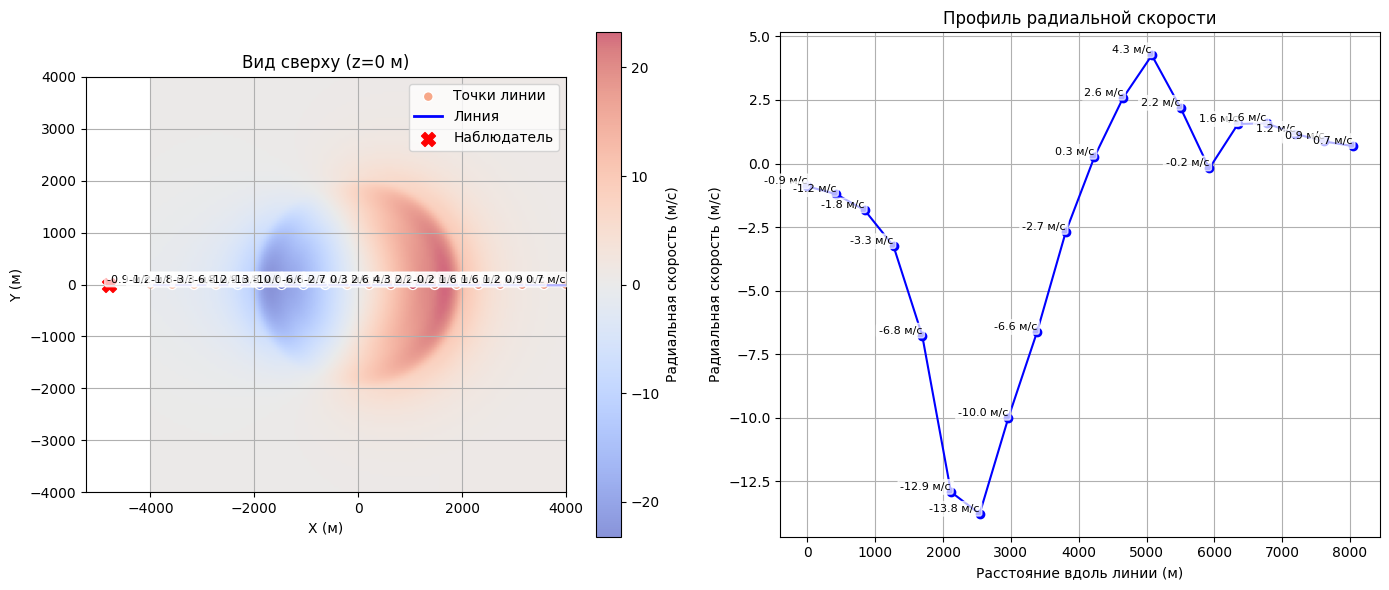

In [91]:
u_data = read_pws_file("../data/111/PWS_NASA_Dataset111_u.faa")
v_data = read_pws_file("../data/111/PWS_NASA_Dataset111_v.faa")
w_data = read_pws_file("../data/111/PWS_NASA_Dataset111_w.faa")

# u_data = read_pws_file("../data/DO-220B Reference Supplement/ADWRS/PWS_NASA_Dataset351_W9_4/PWS_NASA_Dataset351_u.faa")
# v_data = read_pws_file("../data/DO-220B Reference Supplement/ADWRS/PWS_NASA_Dataset351_W9_4/PWS_NASA_Dataset351_v.faa")
# w_data = read_pws_file("../data/DO-220B Reference Supplement/ADWRS/PWS_NASA_Dataset351_W9_4/PWS_NASA_Dataset351_w.faa")

origin = np.array(u_data['origin_m'])  # Начало координат датасета
dx, dy, dz = u_data['resolution_m']     # Шаг сетки
ix, iy, iz = u_data['dimensions']       # Размеры сетки

# Создание сетки в реальных координатах
x = origin[0] + np.arange(ix) * dx
y = origin[1] + np.arange(iy) * dy
z = origin[2] + np.arange(iz) * dz
X, Y, Z = np.meshgrid(x, y, z, indexing='ij')

# Расчет радиальной скорости
x0, y0, z0 =  -4800, 0, 0# Точка наблюдателя
# Параметры линии
azimuth_deg = 0 # Горизонтальный угол
elevation_deg = 5.73  # Вертикальный угол
num_points = 20    # Количество точек



delta_x = X - x0
delta_y = Y - y0
delta_z = Z - z0
r = np.sqrt(delta_x**2 + delta_y**2 + delta_z**2)
with np.errstate(divide='ignore', invalid='ignore'):
    V_radial = (u_data['data'] * delta_x + 
                v_data['data'] * delta_y + 
                w_data['data'] * delta_z) / r
V_radial = np.nan_to_num(V_radial, nan=0.0)



direction = spherical_to_cartesian(azimuth_deg, elevation_deg)

# в реальных координатах
origin_line = np.array([x0, y0, z0])

# пересечения с матрицей
# min_bounds = np.array([x[0], y[0], z[0]])
# max_bounds = np.array([x[-1], y[-1], z[-1]])

matrix_shape = np.array([ix-1, iy-1, iz-1])

direction_normalized = direction / np.array([dx, dy, dz]) 

t_start, t_end = find_intersection(matrix_shape, 
                                  (origin_line - origin)/np.array([dx, dy, dz]), 
                                  direction_normalized)

t_values = np.linspace(t_start, t_end, num_points)
points = origin_line + direction * t_values[:, np.newaxis]  

radial_velocity_values = []
for point in points:
    x_idx = (point[0] - origin[0]) / dx
    y_idx = (point[1] - origin[1]) / dy
    z_idx = (point[2] - origin[2]) / dz
    radial_velocity_values.append(trilinear_interpolation(V_radial, x_idx, y_idx, z_idx))

print(points)
# print(values)
# print(ix)
# istance = [0.0]
distance = [0.0]  # Начальное расстояние 0 метров

for i in range(1, len(points)):
    dx = points[i][0] - points[i-1][0]
    dy = points[i][1] - points[i-1][1]
    dz = points[i][2] - points[i-1][2]
    segment = np.sqrt(dx**2 + dy**2 + dz**2)
    distance.append(distance[-1] + segment)  #

distance = np.array(distance)

plot_line_results(V_radial, z0, x, y, z, points, radial_velocity_values, distance, observer_position=(x0, y0))


In [92]:
def calculate_F_factor(values, distance):
    dv_ds = np.gradient(values, distance)
    print("dv_ds:\n", dv_ds)
    #  ускорение (a = v * dv/ds)
    dt = np.gradient(distance) / np.gradient(distance).mean()  # Приближенное dt
    acceleration = dv_ds / dt
    print("acceleration:\n",acceleration)
    # Расчет F-фактора для каждой точки с окном 1 км
    g = 9.81  # Ускорение свободного падения
    f_factors = []

    for i in range(len(distance)):
        current_dist = distance[i]
        start_dist = current_dist - 500  # 500 метров назад
        end_dist = current_dist + 500    # 500 метров вперед
        
        # Находим индексы границ окна
        left_idx = np.searchsorted(distance, start_dist, side='left')
        right_idx = np.searchsorted(distance, end_dist, side='right')
        
        # Ограничиваем индексы границами массива
        left_idx = max(0, left_idx)
        right_idx = min(len(distance), right_idx)
        
        # Усредняем ускорения в окне
        window_accel = acceleration[left_idx:right_idx]
        if len(window_accel) == 0:
            f_factor = np.nan
        else:
            mean_accel = np.mean(window_accel)
            f_factor = mean_accel  #/g # F-фактор
        print(f"distance: {current_dist}; f-factor {f_factor}; left ")
        
        f_factors.append(f_factor)
    print("f_factors:\n", f_factors)
    return f_factors

values_f_factor = radial_velocity_values
distance_f_factor = distance
f_factors = calculate_F_factor(np.array(values_f_factor), distance_f_factor)
# print(f_factors)
# half_index = len(f_factors) // 2
# f_factors*= -1
# f_factors = np.abs(f_factors)

fig = make_subplots(specs=[[{"secondary_y": True}]])
fig.add_trace(
    go.Scatter(x=distance_f_factor, y=values_f_factor, name='Радиальная скорость'),
    secondary_y=False,
)

fig.add_trace(
    go.Scatter(x=distance_f_factor, y=f_factors, name='F-factor', line=dict(color='red')),
    secondary_y=True,
)

fig.update_layout(
    title='Объединенные данные двух линий',
    xaxis_title='Расстояние, м',
    yaxis_title='Скaорость, м/с',
    yaxis2_title='F/g',
    legend=dict(x=0, y=1),
    width=1000,
    height=600
)

fig.show()

dv_ds:
 [-0.00072358 -0.00111729 -0.0024198  -0.005823   -0.01142428 -0.00828228
  0.00344196  0.00845157  0.00864142  0.00814146  0.00624065  0.00472328
 -0.00046863 -0.00526425 -0.00075357  0.00209961 -0.00045232 -0.00084246
 -0.00057234 -0.00043066]
acceleration:
 [-0.00072358 -0.00111729 -0.0024198  -0.005823   -0.01142428 -0.00828228
  0.00344196  0.00845157  0.00864142  0.00814146  0.00624065  0.00472328
 -0.00046863 -0.00526425 -0.00075357  0.00209961 -0.00045232 -0.00084246
 -0.00057234 -0.00043066]
distance: 0.0; f-factor -0.0009204348520676264; left 
distance: 423.1670126050147; f-factor -0.0014202238469419395; left 
distance: 846.3340252100294; f-factor -0.003120028629899027; left 
distance: 1269.5010378150446; f-factor -0.006555693472336893; left 
distance: 1692.6680504200597; f-factor -0.008509853167211085; left 
distance: 2115.835063025074; f-factor -0.0054215323096765385; left 
distance: 2539.002075630089; f-factor 0.0012037499439939297; left 
distance: 2962.169088235104

<h1><center>Figure B-65: FLWS Scenario 1: Data Set/Time #111, Aligned for Takeoff on Track 90</center></h1>

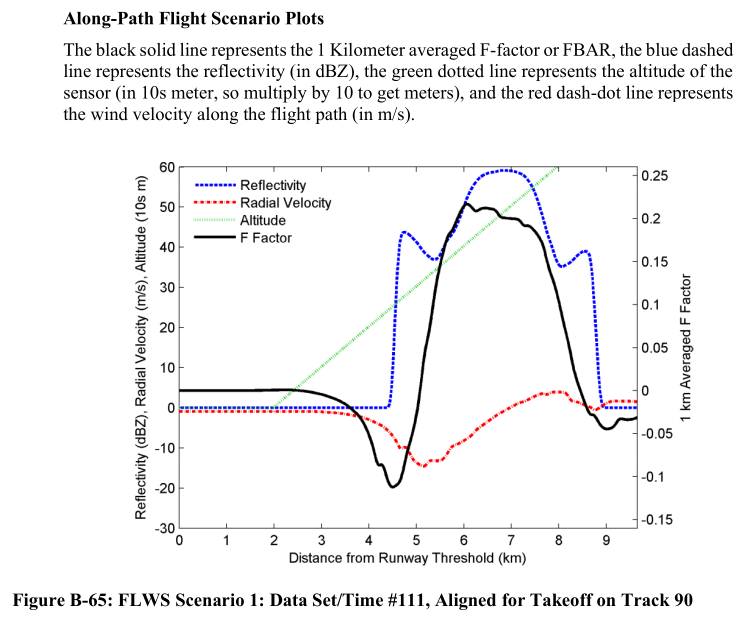


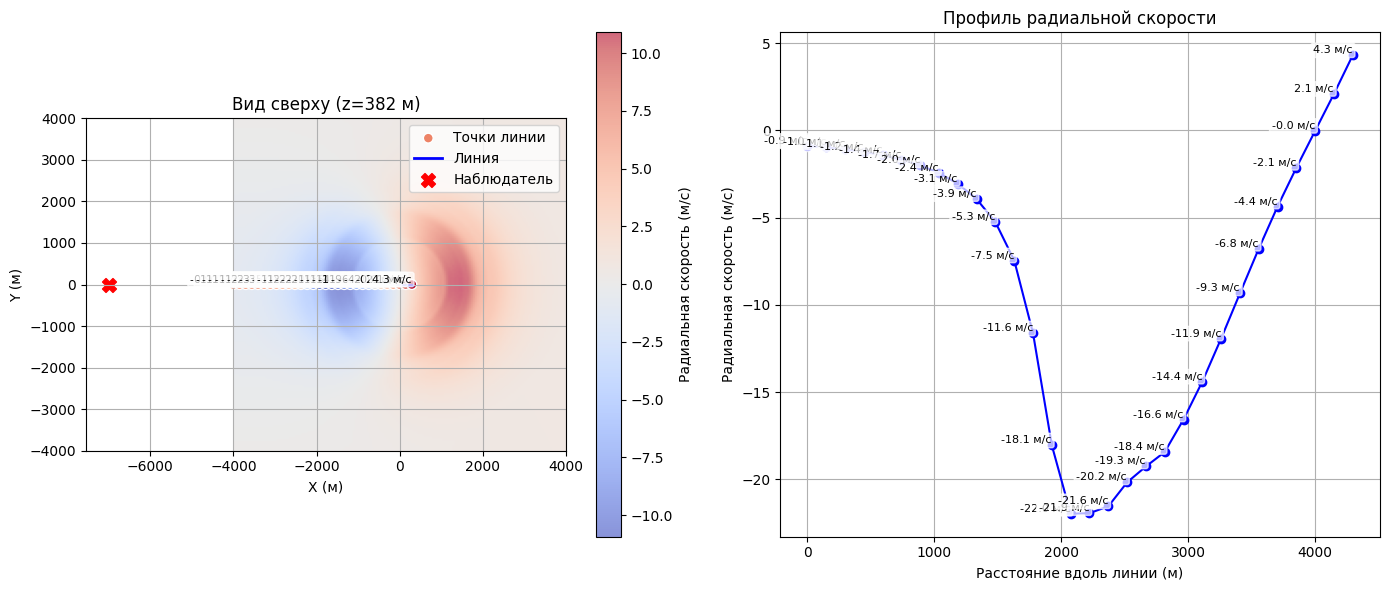

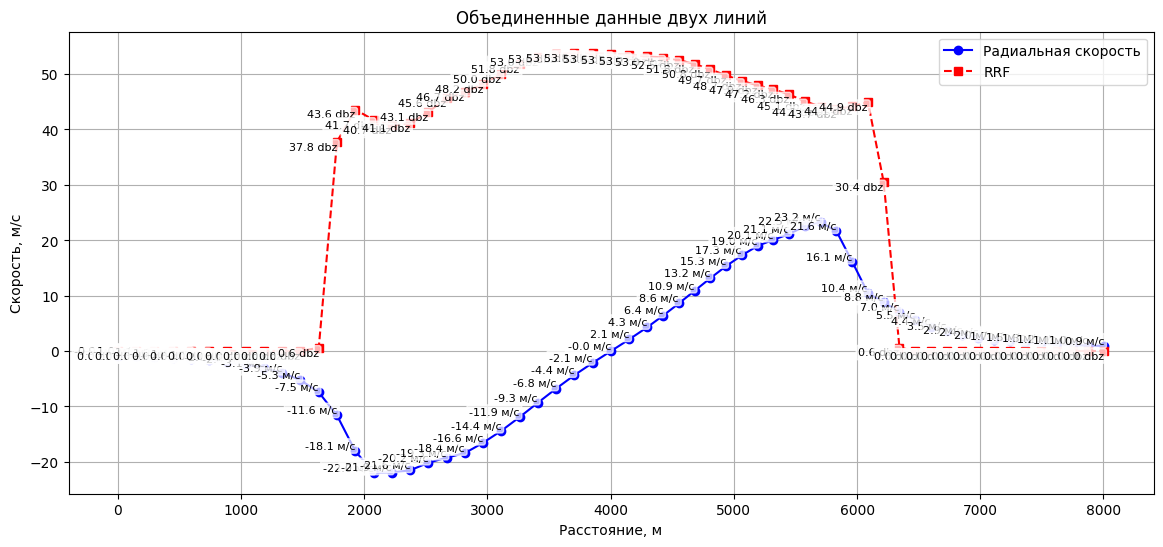

In [95]:
u_data = read_pws_file("../data/111/PWS_NASA_Dataset111_u.faa")
v_data = read_pws_file("../data/111/PWS_NASA_Dataset111_v.faa")
w_data = read_pws_file("../data/111/PWS_NASA_Dataset111_w.faa")

# u_data = read_pws_file("../data/DO-220B Reference Supplement/ADWRS/PWS_NASA_Dataset351_W9_4/PWS_NASA_Dataset351_u.faa")
# v_data = read_pws_file("../data/DO-220B Reference Supplement/ADWRS/PWS_NASA_Dataset351_W9_4/PWS_NASA_Dataset351_v.faa")
# w_data = read_pws_file("../data/DO-220B Reference Supplement/ADWRS/PWS_NASA_Dataset351_W9_4/PWS_NASA_Dataset351_w.faa")

origin = np.array(u_data['origin_m'])  # Начало координат датасета
dx, dy, dz = u_data['resolution_m']     # Шаг сетки
ix, iy, iz = u_data['dimensions']       # Размеры сетки

# Создание сетки в реальных координатах
x = origin[0] + np.arange(ix) * dx
y = origin[1] + np.arange(iy) * dy
z = origin[2] + np.arange(iz) * dz
X, Y, Z = np.meshgrid(x, y, z, indexing='ij')

# Расчет радиальной скорости
# x0, y0, z0 =  -900, 0, 63 # Точка наблюдателя
x0, y0, z0 =  -6996, 0, 382 # Точка наблюдателя 
# Параметры линии
azimuth_deg = 0 # Горизонтальный угол
elevation_deg = -3  # Вертикальный угол
num_points = 30    # Количество точек



delta_x = X - x0
delta_y = Y - y0
delta_z = Z - z0
r = np.sqrt(delta_x**2 + delta_y**2 + delta_z**2)
with np.errstate(divide='ignore', invalid='ignore'):
    V_radial = (u_data['data'] * delta_x + 
                v_data['data'] * delta_y + 
                w_data['data'] * delta_z) / r
V_radial = np.nan_to_num(V_radial, nan=0.0)



direction = spherical_to_cartesian(azimuth_deg, elevation_deg)

# в реальных координатах
origin_line = np.array([x0, y0, z0])

# пересечения с матрицей
# min_bounds = np.array([x[0], y[0], z[0]])
# max_bounds = np.array([x[-1], y[-1], z[-1]])

matrix_shape = np.array([ix-1, iy-1, iz-1])

direction_normalized = direction / np.array([dx, dy, dz]) 

t_start, t_end = find_intersection(matrix_shape, 
                                  (origin_line - origin)/np.array([dx, dy, dz]), 
                                  direction_normalized)

t_values = np.linspace(t_start, t_end, num_points)
points = origin_line + direction * t_values[:, np.newaxis]  

radial_velocity_values = []
for point in points:
    x_idx = (point[0] - origin[0]) / dx
    y_idx = (point[1] - origin[1]) / dy
    z_idx = (point[2] - origin[2]) / dz
    radial_velocity_values.append(trilinear_interpolation(V_radial, x_idx, y_idx, z_idx))

# print(points)
# print(values)
# print(ix)
# istance = [0.0]
distance = [0.0]  # Начальное расстояние 0 метров

for i in range(1, len(points)):
    dx = points[i][0] - points[i-1][0]
    dy = points[i][1] - points[i-1][1]
    dz = points[i][2] - points[i-1][2]
    segment = np.sqrt(dx**2 + dy**2 + dz**2)
    distance.append(distance[-1] + segment)  #

distance = np.array(distance)

plot_line_results(V_radial, z0, x, y, z, points, radial_velocity_values, distance, observer_position=(x0, y0))


# Шаги изменения
dx = -85.86511509
dy = 4.5

first_x = points[0, 0]
first_y = points[0, 1]
first_z = points[0, 2]

new_data = []
for i in range(1, 100):
    new_x = first_x + i * dx
    new_y = first_y 
    new_z = first_z + i * dy
    new_data.append([new_x, new_y, new_z])

new_data = np.array(new_data)
# print(new_data)

# --- Вторая линия ---
u_data = read_pws_file("../data/111/PWS_NASA_Dataset111_u.faa")
v_data = read_pws_file("../data/111/PWS_NASA_Dataset111_v.faa")
w_data = read_pws_file("../data/111/PWS_NASA_Dataset111_w.faa")


# u_data = read_pws_file("../data/DO-220B Reference Supplement/ADWRS/PWS_NASA_Dataset351_W9_4/PWS_NASA_Dataset351_u.faa")
# v_data = read_pws_file("../data/DO-220B Reference Supplement/ADWRS/PWS_NASA_Dataset351_W9_4/PWS_NASA_Dataset351_v.faa")
# w_data = read_pws_file("../data/DO-220B Reference Supplement/ADWRS/PWS_NASA_Dataset351_W9_4/PWS_NASA_Dataset351_w.faa")

origin = np.array(u_data['origin_m'])  # Начало координат датасета
dx, dy, dz = u_data['resolution_m']     # Шаг сетки
ix, iy, iz = u_data['dimensions']       # Размеры сетки

# Создание сетки в реальных координатах

x = origin[0] + np.arange(ix) * dx
y = origin[1] + np.arange(iy) * dy
z = origin[2] + np.arange(iz) * dz
X, Y, Z = np.meshgrid(x, y, z, indexing='ij')
x0_2, y0_2, z0_2 = 292.99, 0, 0 
azimuth_deg_2 = 0
elevation_deg_2 = 0

origin_line_2 = np.array([x0_2, y0_2, z0_2])
direction_2 = spherical_to_cartesian(azimuth_deg_2, elevation_deg_2)
direction_normalized_2 = direction_2 / np.array([dx, dy, dz])

t_start_2, t_end_2 = find_intersection(matrix_shape, 
                                      (origin_line_2 - origin)/np.array([dx, dy, dz]), 
                                      direction_normalized_2)

t_values_2 = np.linspace(t_start_2, t_end_2, num_points)
points_2 = origin_line_2 + direction_2 * t_values_2[:, np.newaxis]

values_2 = []
for point in points_2:
    x_idx = (point[0] - origin[0]) / dx
    y_idx = (point[1] - origin[1]) / dy
    z_idx = (point[2] - origin[2]) / dz
    values_2.append(trilinear_interpolation(V_radial, x_idx, y_idx, z_idx))

distance_2 = [0.0]
for i in range(1, len(points_2)):
    segment = np.linalg.norm(points_2[i] - points_2[i-1])
    distance_2.append(distance_2[-1] + segment)
distance_2 = np.array(distance_2)

values_combined = np.concatenate([radial_velocity_values, values_2[1:]])

distance_2_shifted = distance_2 + distance[-1]
distance_combined = np.concatenate([distance, distance_2_shifted[1:]])

points_combined = np.concatenate([points, points_2[1:]])


rrf_data = read_pws_file("../data/111/PWS_NASA_Dataset111_rrf.faa")
values_rrf = []
for point in points_combined:
    x_idx = (point[0] - origin[0]) / dx
    y_idx = (point[1] - origin[1]) / dy
    z_idx = (point[2] - origin[2]) / dz
    values_rrf.append(trilinear_interpolation(rrf_data['data'], x_idx, y_idx, z_idx))

plt.figure(figsize=(14, 6))
plt.plot(distance_combined, values_combined, label='Радиальная скорость', marker='o', linestyle='-', color='b')
plt.plot(distance_combined, values_rrf, label='RRF', marker='s', linestyle='--', color='r')
plt.xlabel('Расстояние, м')
plt.ylabel('Скорость, м/с')
plt.title('Объединенные данные двух линий')
plt.legend()
plt.grid(True)

for i in range(len(distance_combined)):
    plt.text(
        distance_combined[i], values_combined[i],
        f'{values_combined[i]:.1f} м/с',
        fontsize=8,
        ha='right',
        va='bottom',
        color='black',
        bbox=dict(boxstyle='round,pad=0.2',
                  edgecolor='white',
                  facecolor='white',
                  alpha=0.7)
    )
    plt.text(
        distance_combined[i], values_rrf[i],
        f'{values_rrf[i]:.1f} dbz',
        fontsize=8,
        ha='right',
        va='top',
        color='black',
        bbox=dict(boxstyle='round,pad=0.2',
                  edgecolor='white',
                  facecolor='white',
                  alpha=0.7)
    )

plt.show()


In [9]:
values_combined, len(values_combined)

(array([ -0.88817836,  -1.02481441,  -1.23585767,  -1.55313943,
         -2.03613997,  -2.80531915,  -4.10664835,  -6.61665095,
        -12.79640447, -21.62472537, -21.91851538, -20.49226868,
        -19.13273731, -16.87205802, -13.49695803,  -9.62147908,
         -5.75027708,  -2.25363717,   0.96485673,   4.3123922 ,
          7.53910238,  11.00402464,  14.43689562,  17.46758972,
         19.71451153,  21.31997288,  23.12669094,  20.90168739,
         11.3068917 ,   8.32467082,   5.83313317,   4.09710931,
          2.98466456,   2.25745746,   1.76643702,   1.42719017,
          1.18863658,   1.02102378,   0.90435448]),
 39)

In [10]:
distance_combined, len(distance_combined)

(array([   0.        ,  226.25714148,  452.51428296,  678.77142444,
         905.02856592, 1131.28570741, 1357.54284889, 1583.79999037,
        1810.05713185, 2036.31427333, 2262.57141481, 2488.82855629,
        2715.08569777, 2941.34283925, 3167.59998074, 3393.85712222,
        3620.1142637 , 3846.37140518, 4072.62854666, 4298.88568814,
        4493.99147498, 4689.09726183, 4884.20304867, 5079.30883551,
        5274.41462235, 5469.52040919, 5664.62619604, 5859.73198288,
        6054.83776972, 6249.94355656, 6445.0493434 , 6640.15513025,
        6835.26091709, 7030.36670393, 7225.47249077, 7420.57827762,
        7615.68406446, 7810.7898513 , 8005.89563814]),
 39)

In [11]:
print(points_combined)

[[-4000.             0.           224.98629327]
 [-3774.05293607     0.           213.14490941]
 [-3548.10587214     0.           201.30352556]
 [-3322.1588082      0.           189.4621417 ]
 [-3096.21174427     0.           177.62075784]
 [-2870.26468034     0.           165.77937399]
 [-2644.31761641     0.           153.93799013]
 [-2418.37055247     0.           142.09660627]
 [-2192.42348854     0.           130.25522242]
 [-1966.47642461     0.           118.41383856]
 [-1740.52936068     0.           106.57245471]
 [-1514.58229675     0.            94.73107085]
 [-1288.63523281     0.            82.88968699]
 [-1062.68816888     0.            71.04830314]
 [ -836.74110495     0.            59.20691928]
 [ -610.79404102     0.            47.36553542]
 [ -384.84697708     0.            35.52415157]
 [ -158.89991315     0.            23.68276771]
 [   67.04715078     0.            11.84138386]
 [  292.99421471     0.             0.        ]
 [  488.09578684     0.             0.  

In [96]:
def calculate_F_factor(values, distance):
    dv_ds = np.gradient(values, distance)
    print("dv_ds:\n", dv_ds)
    #  ускорение (a = v * dv/ds)
    dt = np.gradient(distance) / np.gradient(distance).mean()  # Приближенное dt
    acceleration = dv_ds / dt
    print("acceleration:\n",acceleration)
    # Расчет F-фактора для каждой точки с окном 1 км
    g = 9.81  # Ускорение свободного падения
    f_factors = []

    for i in range(len(distance)):
        current_dist = distance[i]
        start_dist = current_dist - 500  # 500 метров назад
        end_dist = current_dist + 500    # 500 метров вперед
        
        # Находим индексы границ окна
        left_idx = np.searchsorted(distance, start_dist, side='left')
        right_idx = np.searchsorted(distance, end_dist, side='right')
        
        # Ограничиваем индексы границами массива
        left_idx = max(0, left_idx)
        right_idx = min(len(distance), right_idx)
        
        # Усредняем ускорения в окне
        window_accel = acceleration[left_idx:right_idx]
        if len(window_accel) == 0:
            f_factor = np.nan
        else:
            mean_accel = np.mean(window_accel)
            f_factor = mean_accel  #/g # F-фактор
        print(f"distance: {current_dist}; f-factor {f_factor}; left ")
        
        f_factors.append(f_factor)
    print("f_factors:\n", f_factors)
    return f_factors

values_f_factor = values_combined
distance_f_factor = distance_combined
f_factors = calculate_F_factor(np.array(values_f_factor), distance_f_factor)
# print(f_factors)
# half_index = len(f_factors) // 2
# f_factors*= -1
# f_factors = np.abs(f_factors)

fig = make_subplots(specs=[[{"secondary_y": True}]])
fig.add_trace(
    go.Scatter(x=distance_f_factor, y=values_f_factor, name='Радиальная скорость'),
    secondary_y=False,
)

fig.add_trace(
    go.Scatter(x=distance_f_factor, y=f_factors, name='F-factor', line=dict(color='red')),
    secondary_y=True,
)

fig.update_layout(
    title='Объединенные данные двух линий',
    xaxis_title='Расстояние, м',
    yaxis_title='Скaорость, м/с',
    yaxis2_title='F/g',
    legend=dict(x=0, y=1),
    width=1000,
    height=600
)

fig.show()

dv_ds:
 [-0.00055122 -0.00065034 -0.00086771 -0.00113304 -0.00148053 -0.0019535
 -0.00261319 -0.00357463 -0.0050441  -0.00743994 -0.01187286 -0.02152047
 -0.03577959 -0.03487083 -0.01308942  0.00144093  0.00596017  0.00771181
  0.00587206  0.00908343  0.01360602  0.01565003  0.01706707  0.01736838
  0.01679026  0.015658    0.01464435  0.0142884   0.01462444  0.0157028
  0.01676368  0.01753219  0.01783349  0.01741886  0.01610219  0.01425456
  0.0109464   0.00835057  0.00958635  0.00821496 -0.00356153 -0.02779876
 -0.04372897 -0.02875161 -0.01325361 -0.01255691 -0.01037182 -0.0078618
 -0.00587246 -0.00442481 -0.00336882 -0.00261311 -0.00204028 -0.00161121
 -0.001279   -0.00101645 -0.00080381 -0.00063605 -0.00056479]
acceleration:
 [-0.00051328 -0.00060557 -0.00080798 -0.00105504 -0.0013786  -0.00181902
 -0.0024333  -0.00332855 -0.00469686 -0.00692777 -0.01105553 -0.02003899
 -0.0333165  -0.0324703  -0.01218834  0.00134174  0.00554987  0.00718093
  0.00546782  0.00845812  0.01266937  0.01

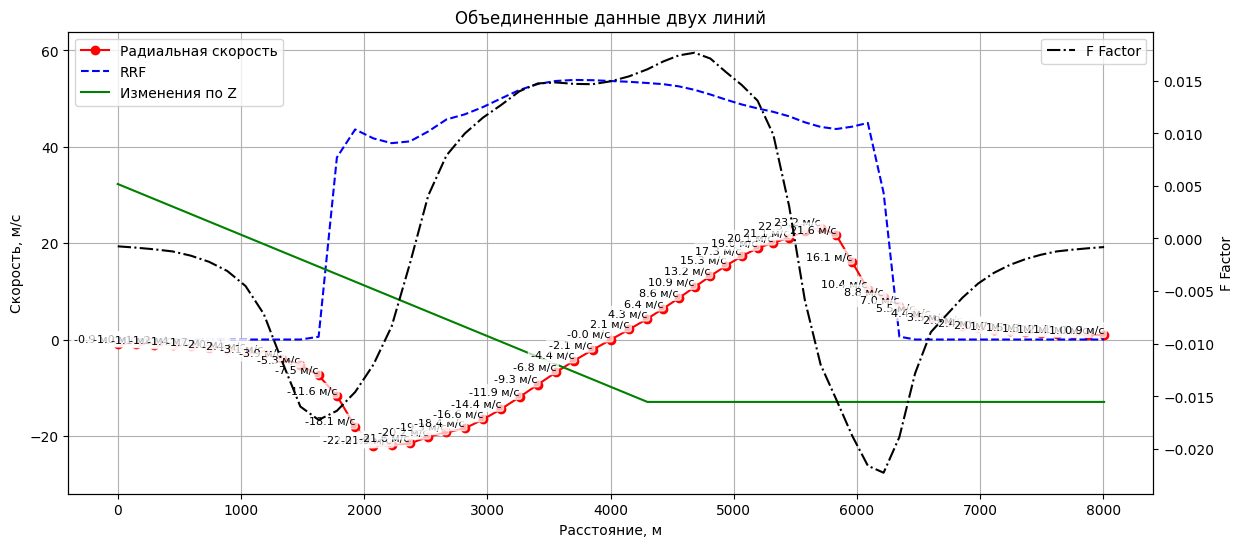

In [97]:
fig, ax1 = plt.subplots(figsize=(14, 6))

# Нормализация и смещение Z-значений
z_min, z_max = points_combined[:, 2].min(), points_combined[:, 2].max()
v_min, v_max = min(values_combined), max(values_combined)
scaled_z = (points_combined[:, 2] - z_min) / (z_max - z_min) * (v_max - v_min) + v_min
scaled_z += (v_max - v_min) * 0.2  # Смещение на 20% от диапазона скорости

# Линия радиальной скорости (красная)
ax1.plot(distance_combined, values_combined, label='Радиальная скорость', marker='o', linestyle='-', color='r')

# Линия RRF (синяя)
ax1.plot(distance_combined, values_rrf, label='RRF', linestyle='--', color='b')

# Линия изменений по Z (зелёная) - нормализованная и смещённая
ax1.plot(distance_combined, scaled_z, label='Изменения по Z', linestyle='-', color='g')

ax1.set_xlabel('Расстояние, м')
ax1.set_ylabel('Скорость, м/с')
ax1.set_title('Объединенные данные двух линий')
ax1.legend(loc='upper left')
ax1.grid(True)

# Подписи значений у профиля
for i in range(len(distance_combined)):
    ax1.text(
        distance_combined[i], values_combined[i],
        f'{values_combined[i]:.1f} м/с',
        fontsize=8,
        ha='right',
        va='bottom',
        color='black',
        bbox=dict(boxstyle='round,pad=0.2',
                  edgecolor='white',
                  facecolor='white',
                  alpha=0.7)
    )

all_values = np.concatenate([values_combined, values_rrf, scaled_z])
ax1.set_ylim([all_values.min() - 10, all_values.max() + 10])

ax2 = ax1.twinx()
ax2.plot(distance_combined, f_factors, label='F Factor', linestyle='-.', color='k')
ax2.set_ylabel('F Factor')
ax2.legend(loc='upper right')

plt.show()

<h1><center>Figure B-66: FLWS Scenario 2: Data Set/Time #111, Straight-In Approach on Track 90</center></h1>

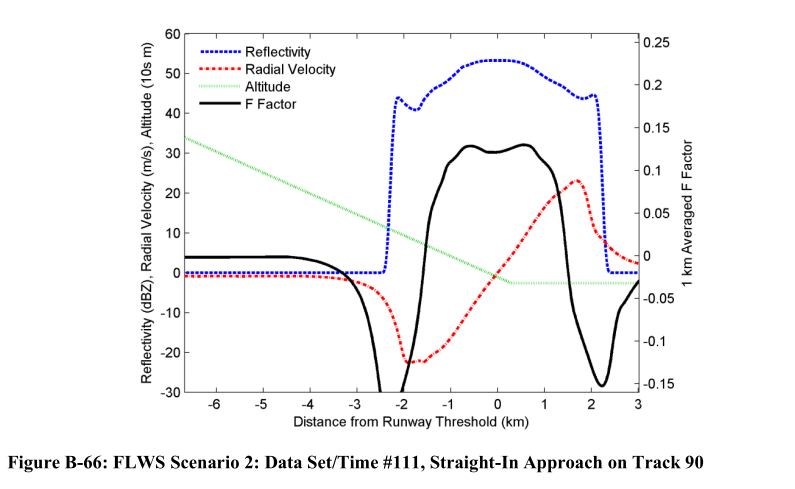


[[-1800.         -8880.           370.70288558]
 [-1800.         -8507.71408262   351.19220739]
 [-1800.         -8135.42816524   331.6815292 ]
 [-1800.         -7763.14224786   312.17085101]
 [-1800.         -7390.85633048   292.66017282]
 [-1800.         -7018.5704131    273.14949464]
 [-1800.         -6646.28449571   253.63881645]
 [-1800.         -6273.99857833   234.12813826]
 [-1800.         -5901.71266095   214.61746007]
 [-1800.         -5529.42674357   195.10678188]
 [-1800.         -5157.14082619   175.59610369]
 [-1800.         -4784.85490881   156.08542551]
 [-1800.         -4412.56899143   136.57474732]
 [-1800.         -4040.28307405   117.06406913]
 [-1800.         -3667.99715667    97.55339094]
 [-1800.         -3295.71123929    78.04271275]
 [-1800.         -2923.42532191    58.53203456]
 [-1800.         -2551.13940453    39.02135638]
 [-1800.         -2178.85348714    19.51067819]
 [-1800.         -1806.56756976     0.        ]]


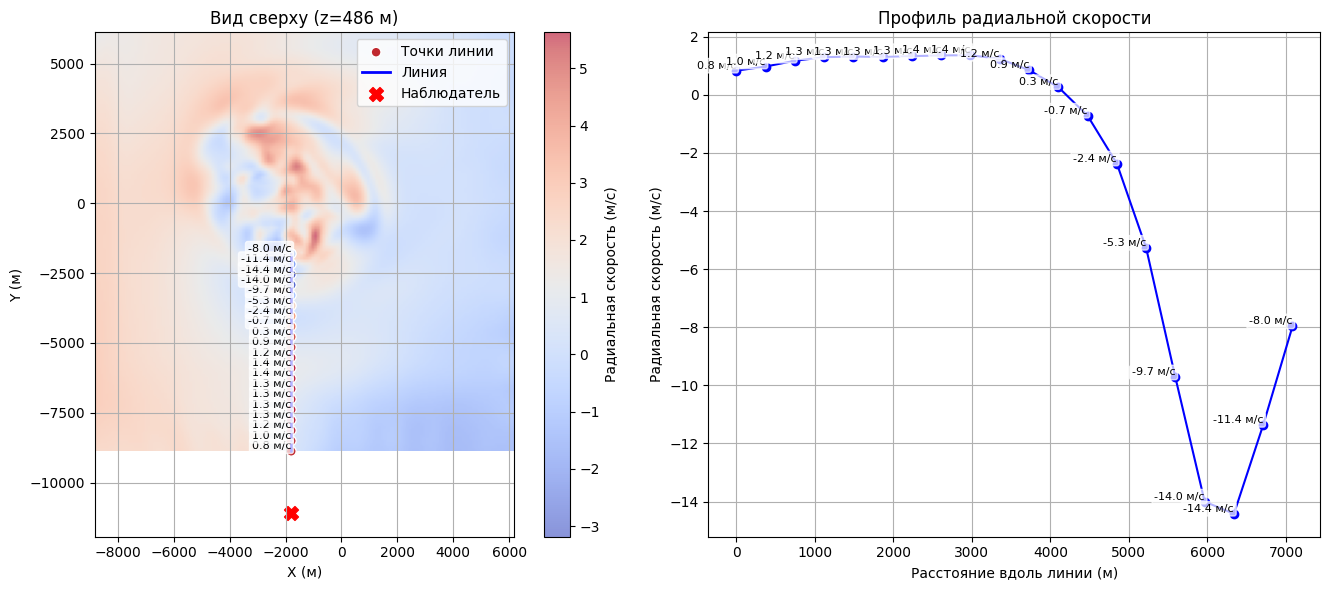

In [ ]:
# u_data = read_pws_file("../data/111/PWS_NASA_Dataset111_u.faa")
# v_data = read_pws_file("../data/111/PWS_NASA_Dataset111_v.faa")
# w_data = read_pws_file("../data/111/PWS_NASA_Dataset111_w.faa")

# u_data = read_pws_file("../data/DO-220B Reference Supplement/ADWRS/PWS_NASA_Dataset351_W9_4/PWS_NASA_Dataset351_u.faa")
# v_data = read_pws_file("../data/DO-220B Reference Supplement/ADWRS/PWS_NASA_Dataset351_W9_4/PWS_NASA_Dataset351_v.faa")
# w_data = read_pws_file("../data/DO-220B Reference Supplement/ADWRS/PWS_NASA_Dataset351_W9_4/PWS_NASA_Dataset351_w.faa")

u_data = read_pws_file("../data/DO-220B Reference Supplement/ADWRS/PWS_NASA_Dataset237_W9_2/PWS_NASA_Dataset237_u.faa")
v_data = read_pws_file("../data/DO-220B Reference Supplement/ADWRS/PWS_NASA_Dataset237_W9_2/PWS_NASA_Dataset237_v.faa")
w_data = read_pws_file("../data/DO-220B Reference Supplement/ADWRS/PWS_NASA_Dataset237_W9_2/PWS_NASA_Dataset237_w.faa")


origin = np.array(u_data['origin_m'])  # Начало координат датасета
dx, dy, dz = u_data['resolution_m']     # Шаг сетки
ix, iy, iz = u_data['dimensions']       # Размеры сетки

# Создание сетки в реальных координатах
x = origin[0] + np.arange(ix) * dx
y = origin[1] + np.arange(iy) * dy
z = origin[2] + np.arange(iz) * dz
X, Y, Z = np.meshgrid(x, y, z, indexing='ij')

# Расчет радиальной скорости
# x0, y0, z0 =  -1800, -1900, 63# Точка наблюдателя
x0, y0, z0 =  -1800, -11080, 486#  [ -8980.17667522      0.            485.98629327]

# Параметры линии
azimuth_deg = 90 # Горизонтальный угол
elevation_deg = -3  # Вертикальный угол
num_points = 20    # Количество точек



delta_x = X - x0
delta_y = Y - y0
delta_z = Z - z0
r = np.sqrt(delta_x**2 + delta_y**2 + delta_z**2)
with np.errstate(divide='ignore', invalid='ignore'):
    V_radial = (u_data['data'] * delta_x + 
                v_data['data'] * delta_y + 
                w_data['data'] * delta_z) / r
V_radial = np.nan_to_num(V_radial, nan=0.0)



direction = spherical_to_cartesian(azimuth_deg, elevation_deg)

# в реальных координатах
origin_line = np.array([x0, y0, z0])

# пересечения с матрицей
# min_bounds = np.array([x[0], y[0], z[0]])
# max_bounds = np.array([x[-1], y[-1], z[-1]])

matrix_shape = np.array([ix-1, iy-1, iz-1])

direction_normalized = direction / np.array([dx, dy, dz]) 

t_start, t_end = find_intersection(matrix_shape, 
                                  (origin_line - origin)/np.array([dx, dy, dz]), 
                                  direction_normalized)

t_values = np.linspace(t_start, t_end, num_points)
points = origin_line + direction * t_values[:, np.newaxis]  

radial_velocity_values = []
for point in points:
    x_idx = (point[0] - origin[0]) / dx
    y_idx = (point[1] - origin[1]) / dy
    z_idx = (point[2] - origin[2]) / dz
    radial_velocity_values.append(trilinear_interpolation(V_radial, x_idx, y_idx, z_idx))

print(points)
# print(values)
# print(ix)
# istance = [0.0]
distance = [0.0]  # Начальное расстояние 0 метров

for i in range(1, len(points)):
    dx = points[i][0] - points[i-1][0]
    dy = points[i][1] - points[i-1][1]
    dz = points[i][2] - points[i-1][2]
    segment = np.sqrt(dx**2 + dy**2 + dz**2)
    distance.append(distance[-1] + segment)  #

distance = np.array(distance)

plot_line_results(V_radial, z0, x, y, z, points, radial_velocity_values, distance, observer_position=(x0, y0))


<h1><center>Figure B-67: FLWS Scenario 3: Data Set/Time #237, Straight-In Approach on Track 180</center></h1>

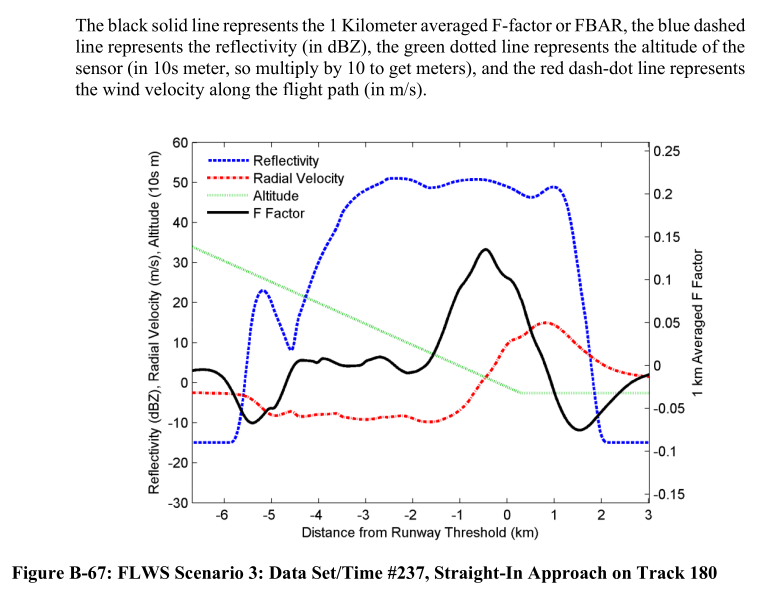

[[-8834.         -1100.           377.88965862]
 [-8454.49661953 -1100.           358.00072922]
 [-8074.99323906 -1100.           338.11179982]
 [-7695.48985858 -1100.           318.22287042]
 [-7315.98647811 -1100.           298.33394101]
 [-6936.48309764 -1100.           278.44501161]
 [-6556.97971717 -1100.           258.55608221]
 [-6177.47633669 -1100.           238.66715281]
 [-5797.97295622 -1100.           218.77822341]
 [-5418.46957575 -1100.           198.88929401]
 [-5038.96619528 -1100.           179.00036461]
 [-4659.46281481 -1100.           159.11143521]
 [-4279.95943433 -1100.           139.22250581]
 [-3900.45605386 -1100.           119.33357641]
 [-3520.95267339 -1100.            99.444647  ]
 [-3141.44929292 -1100.            79.5557176 ]
 [-2761.94591244 -1100.            59.6667882 ]
 [-2382.44253197 -1100.            39.7778588 ]
 [-2002.9391515  -1100.            19.8889294 ]
 [-1623.43577103 -1100.             0.        ]]


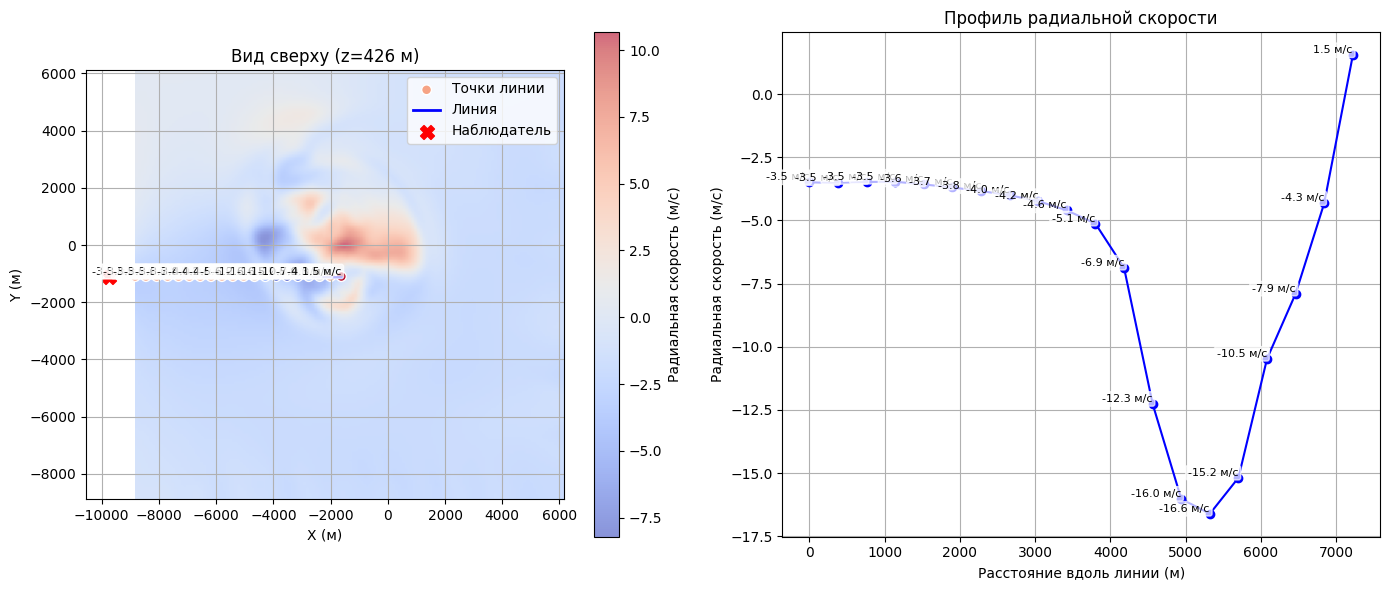

In [ ]:
# u_data = read_pws_file("../data/111/PWS_NASA_Dataset111_u.faa")
# v_data = read_pws_file("../data/111/PWS_NASA_Dataset111_v.faa")
# w_data = read_pws_file("../data/111/PWS_NASA_Dataset111_w.faa")

# u_data = read_pws_file("../data/DO-220B Reference Supplement/ADWRS/PWS_NASA_Dataset351_W9_4/PWS_NASA_Dataset351_u.faa")
# v_data = read_pws_file("../data/DO-220B Reference Supplement/ADWRS/PWS_NASA_Dataset351_W9_4/PWS_NASA_Dataset351_v.faa")
# w_data = read_pws_file("../data/DO-220B Reference Supplement/ADWRS/PWS_NASA_Dataset351_W9_4/PWS_NASA_Dataset351_w.faa")

u_data = read_pws_file("../data/DO-220B Reference Supplement/ADWRS/PWS_NASA_Dataset237_W9_2/PWS_NASA_Dataset237_u.faa")
v_data = read_pws_file("../data/DO-220B Reference Supplement/ADWRS/PWS_NASA_Dataset237_W9_2/PWS_NASA_Dataset237_v.faa")
w_data = read_pws_file("../data/DO-220B Reference Supplement/ADWRS/PWS_NASA_Dataset237_W9_2/PWS_NASA_Dataset237_w.faa")


origin = np.array(u_data['origin_m'])  # Начало координат датасета
dx, dy, dz = u_data['resolution_m']     # Шаг сетки
ix, iy, iz = u_data['dimensions']       # Размеры сетки

# Создание сетки в реальных координатах
x = origin[0] + np.arange(ix) * dx
y = origin[1] + np.arange(iy) * dy
z = origin[2] + np.arange(iz) * dz
X, Y, Z = np.meshgrid(x, y, z, indexing='ij')

# Расчет радиальной скорости
x0, y0, z0 =  -9752, -1100, 426# Точка наблюдателя
 # [ -9752.96271103      0.            526.48629327]
# Параметры линии
azimuth_deg = 0 # Горизонтальный угол
elevation_deg = -3  # Вертикальный угол
num_points = 20    # Количество точек



delta_x = X - x0
delta_y = Y - y0
delta_z = Z - z0
r = np.sqrt(delta_x**2 + delta_y**2 + delta_z**2)
with np.errstate(divide='ignore', invalid='ignore'):
    V_radial = (u_data['data'] * delta_x + 
                v_data['data'] * delta_y + 
                w_data['data'] * delta_z) / r
V_radial = np.nan_to_num(V_radial, nan=0.0)



direction = spherical_to_cartesian(azimuth_deg, elevation_deg)

# в реальных координатах
origin_line = np.array([x0, y0, z0])

# пересечения с матрицей
# min_bounds = np.array([x[0], y[0], z[0]])
# max_bounds = np.array([x[-1], y[-1], z[-1]])

matrix_shape = np.array([ix-1, iy-1, iz-1])

direction_normalized = direction / np.array([dx, dy, dz]) 

t_start, t_end = find_intersection(matrix_shape, 
                                  (origin_line - origin)/np.array([dx, dy, dz]), 
                                  direction_normalized)

t_values = np.linspace(t_start, t_end, num_points)
points = origin_line + direction * t_values[:, np.newaxis]  

radial_velocity_values = []
for point in points:
    x_idx = (point[0] - origin[0]) / dx
    y_idx = (point[1] - origin[1]) / dy
    z_idx = (point[2] - origin[2]) / dz
    radial_velocity_values.append(trilinear_interpolation(V_radial, x_idx, y_idx, z_idx))

print(points)
# print(values)
# print(ix)
# istance = [0.0]
distance = [0.0]  # Начальное расстояние 0 метров

for i in range(1, len(points)):
    dx = points[i][0] - points[i-1][0]
    dy = points[i][1] - points[i-1][1]
    dz = points[i][2] - points[i-1][2]
    segment = np.sqrt(dx**2 + dy**2 + dz**2)
    distance.append(distance[-1] + segment)  #

distance = np.array(distance)

plot_line_results(V_radial, z0, x, y, z, points, radial_velocity_values, distance, observer_position=(x0, y0))


<h1><center>Figure B-68: FLWS Scenario 4: Data Set/Time #237, Straight-In Approach on Track 90, Below</center></h1>

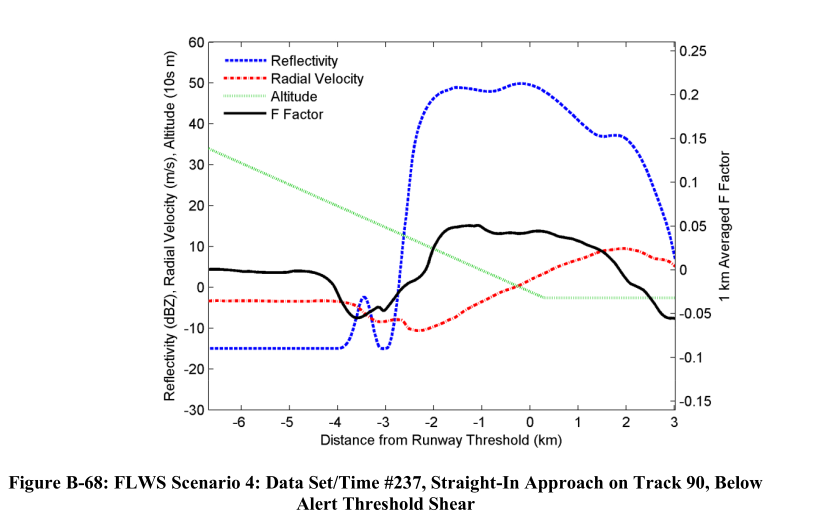

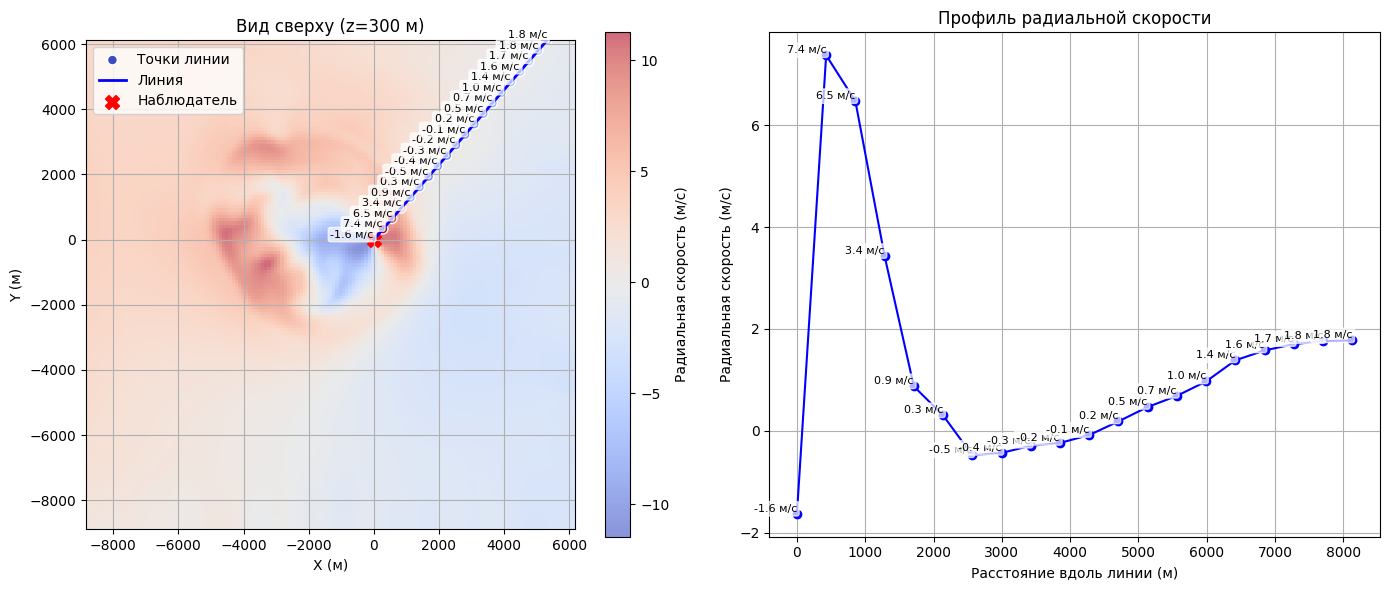

In [ ]:
origin = np.array(u_data['origin_m'])  # Начало координат датасета
dx, dy, dz = u_data['resolution_m']     # Шаг сетки
ix, iy, iz = u_data['dimensions'] 
x = origin[0] + np.arange(ix) * dx
y = origin[1] + np.arange(iy) * dy
z = origin[2] + np.arange(iz) * dz
X, Y, Z = np.meshgrid(x, y, z, indexing='ij')

# Расчет радиальной скорости
x0, y0, z0 =  0, 0, 300 # Точка наблюдателя
# Параметры линии
azimuth_deg = 49    # Горизонтальный угол
elevation_deg = 4  # Вертикальный угол
num_points = 20    # Количество точек
delta_x = X - x0
delta_y = Y - y0
delta_z = Z - z0
r = np.sqrt(delta_x**2 + delta_y**2 + delta_z**2)
with np.errstate(divide='ignore', invalid='ignore'):
    V_radial = (u_data['data'] * delta_x + 
                v_data['data'] * delta_y + 
                w_data['data'] * delta_z) / r
V_radial = np.nan_to_num(V_radial, nan=0.0)



direction = spherical_to_cartesian(azimuth_deg, elevation_deg)
origin_line = np.array([x0, y0, z0])
# min_bounds = np.array([x[0], y[0], z[0]])
# max_bounds = np.array([x[-1], y[-1], z[-1]])
matrix_shape = np.array([ix-1, iy-1, iz-1])

direction_normalized = direction / np.array([dx, dy, dz]) 

t_start, t_end = find_intersection(matrix_shape, 
                                  (origin_line - origin)/np.array([dx, dy, dz]), 
                                  direction_normalized)

t_values = np.linspace(t_start, t_end, num_points)
points = origin_line + direction * t_values[:, np.newaxis]  
radial_velocity_values = []
for point in points:
    x_idx = (point[0] - origin[0]) / dx
    y_idx = (point[1] - origin[1]) / dy
    z_idx = (point[2] - origin[2]) / dz
    radial_velocity_values.append(trilinear_interpolation(V_radial, x_idx, y_idx, z_idx))
# print(points)
# print(values)
# print(ix)
# istance = [0.0]
distance = [0.0]  

for i in range(1, len(points)):
    dx = points[i][0] - points[i-1][0]
    dy = points[i][1] - points[i-1][1]
    dz = points[i][2] - points[i-1][2]
    segment = np.sqrt(dx**2 + dy**2 + dz**2)
    distance.append(distance[-1] + segment)  #
distance = np.array(distance)
plot_line_results(V_radial, z0, x, y, z, points, radial_velocity_values, distance, observer_position=(x0, y0))

<h1><center>График — 5. Линия с измененным вертикальным углом на +4 и горизонтальный угол на +4</center></h1>

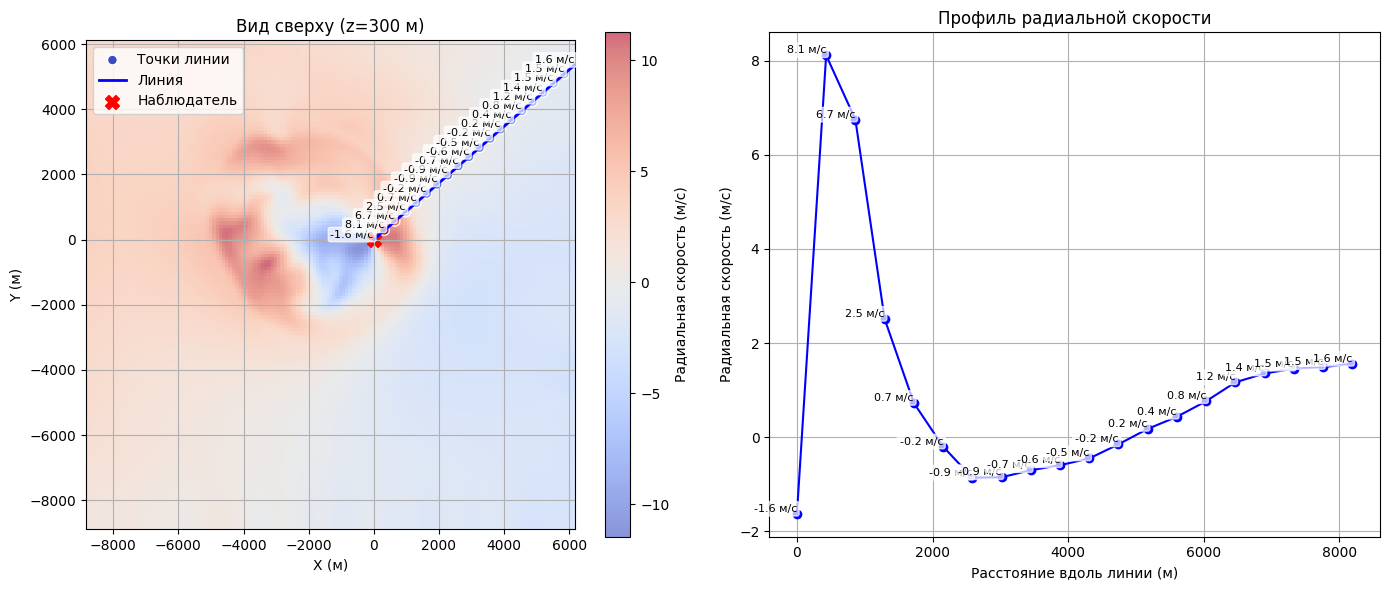

In [ ]:
origin = np.array(u_data['origin_m'])  # Начало координат датасета
dx, dy, dz = u_data['resolution_m']     # Шаг сетки
ix, iy, iz = u_data['dimensions'] 
x = origin[0] + np.arange(ix) * dx
y = origin[1] + np.arange(iy) * dy
z = origin[2] + np.arange(iz) * dz
X, Y, Z = np.meshgrid(x, y, z, indexing='ij')

# Расчет радиальной скорости
x0, y0, z0 =  0, 0, 300 # Точка наблюдателя
# Параметры линии
azimuth_deg = 41    # Горизонтальный угол
elevation_deg = 4  # Вертикальный угол
num_points = 20    # Количество точек
delta_x = X - x0
delta_y = Y - y0
delta_z = Z - z0
r = np.sqrt(delta_x**2 + delta_y**2 + delta_z**2)
with np.errstate(divide='ignore', invalid='ignore'):
    V_radial = (u_data['data'] * delta_x + 
                v_data['data'] * delta_y + 
                w_data['data'] * delta_z) / r
V_radial = np.nan_to_num(V_radial, nan=0.0)



direction = spherical_to_cartesian(azimuth_deg, elevation_deg)
origin_line = np.array([x0, y0, z0])
# min_bounds = np.array([x[0], y[0], z[0]])
# max_bounds = np.array([x[-1], y[-1], z[-1]])
matrix_shape = np.array([ix-1, iy-1, iz-1])

direction_normalized = direction / np.array([dx, dy, dz]) 

t_start, t_end = find_intersection(matrix_shape, 
                                  (origin_line - origin)/np.array([dx, dy, dz]), 
                                  direction_normalized)

t_values = np.linspace(t_start, t_end, num_points)
points = origin_line + direction * t_values[:, np.newaxis]  
radial_velocity_values = []
for point in points:
    x_idx = (point[0] - origin[0]) / dx
    y_idx = (point[1] - origin[1]) / dy
    z_idx = (point[2] - origin[2]) / dz
    radial_velocity_values.append(trilinear_interpolation(V_radial, x_idx, y_idx, z_idx))
# print(points)
# print(values)
# print(ix)
# istance = [0.0]
distance = [0.0]  

for i in range(1, len(points)):
    dx = points[i][0] - points[i-1][0]
    dy = points[i][1] - points[i-1][1]
    dz = points[i][2] - points[i-1][2]
    segment = np.sqrt(dx**2 + dy**2 + dz**2)
    distance.append(distance[-1] + segment)  #
distance = np.array(distance)
plot_line_results(V_radial, z0, x, y, z, points, radial_velocity_values, distance, observer_position=(x0, y0))

<h1><center>График — 6. Линия с измененным вертикальным углом на +4 и горизонтальный угол на -4</center></h1>